# Adding Dynamic Columns

In [28]:
import pandas as pd

titanic = pd.read_csv('../../data/titanic.csv')
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [29]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pclass     1309 non-null   int64 
 1   survived   1309 non-null   int64 
 2   name       1309 non-null   object
 3   sex        1309 non-null   object
 4   age        1309 non-null   object
 5   sibsp      1309 non-null   int64 
 6   parch      1309 non-null   int64 
 7   ticket     1309 non-null   object
 8   fare       1309 non-null   object
 9   cabin      1309 non-null   object
 10  embarked   1309 non-null   object
 11  boat       1309 non-null   object
 12  body       1309 non-null   object
 13  home.dest  1309 non-null   object
dtypes: int64(4), object(10)
memory usage: 143.3+ KB


##### Adding a total_relatives calculated column

In [30]:
total_relatives = (titanic['parch'] + titanic['sibsp'])
titanic.insert(7, '# of Relatives', total_relatives)
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,# of Relatives,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,3,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,3,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,3,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,3,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [31]:
total_relatives = (titanic['parch'] + titanic['sibsp'])
total_relatives

0       0
1       3
2       3
3       3
4       3
       ..
1304    1
1305    1
1306    0
1307    0
1308    0
Length: 1309, dtype: int64

In [32]:
titanic.sort_values('# of Relatives', ascending=False).head()

,pclass,survived,name,sex,age,sibsp,parch,# of Relatives,ticket,fare,cabin,embarked,boat,body,home.dest
1177,3,0,"Sage, Mr. Frederick",male,?,8,2,10,CA. 2343,69.55,?,S,?,?,?
1179,3,0,"Sage, Mr. John George",male,?,1,9,10,CA. 2343,69.55,?,S,?,?,?
1173,3,0,"Sage, Miss. Constance Gladys",female,?,8,2,10,CA. 2343,69.55,?,S,?,?,?
1170,3,0,"Sage, Master. Thomas Henry",male,?,8,2,10,CA. 2343,69.55,?,S,?,?,?
1172,3,0,"Sage, Miss. Ada",female,?,8,2,10,CA. 2343,69.55,?,S,?,?,?


### Find the per square foot price of houses

In [34]:
import pandas as pd

houses = pd.read_csv('../../data/kc_house_data.csv')
houses.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [35]:
houses.insert(3, 'price/sqft', houses['price'] / houses['sqft_living'])
houses.head()

,id,date,price,price/sqft,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,188.050847,3,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,209.338521,3,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,233.766234,2,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,308.163265,4,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,303.571429,3,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [36]:
houses.sort_values(['price/sqft'], ascending=False).head()

,id,date,price,price/sqft,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
19336,6021500970,20150407T000000,874950.0,810.138889,2,1.00,1080,4000,1.0,0,...,7,1080,0,1940,0,98117,47.6902,-122.387,1530,4240
4013,724069059,20140509T000000,2400000.0,800.000000,3,2.25,3000,11665,1.5,1,...,11,3000,0,2001,0,98075,47.5884,-122.086,3000,15959
10446,1118000320,20150508T000000,3400000.0,798.122066,4,4.00,4260,11765,2.0,0,...,11,3280,980,1939,2010,98112,47.6380,-122.288,4260,10408
8623,6303400395,20150130T000000,325000.0,792.682927,1,0.75,410,8636,1.0,0,...,4,410,0,1953,0,98146,47.5077,-122.357,1190,8636
9314,4389200610,20141201T000000,903000.0,792.105263,2,1.50,1140,7800,1.0,0,...,6,1140,0,1947,0,98004,47.6142,-122.209,2020,7800


<Axes: xlabel='zipcode'>

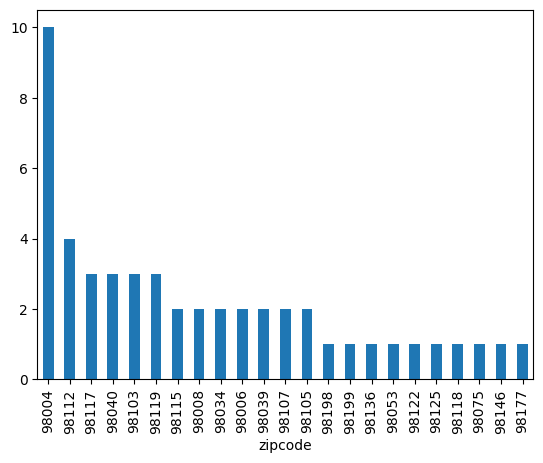

In [41]:
houses.sort_values(['price/sqft'], ascending=False).head(50)['zipcode'].value_counts().plot(kind='bar')